# **Hackathon Project: Where You Wanna Live**

## Team Objectives

* As a team we need to agree on datasets that match not only our interests but one that the team can work on together. 

* Gather information from the chosen dataset that the three of us can share near the deadline.

* Collaborate effectively when delivering our research in a presentation.

## My Task

* Research the cost of living in Netherlands, Luxembourg and Switzerland.

* My team know how to present in Streamlit, I have tasked myself to make charts in Tableau to see a feature comparison. 

## Inputs & Outputs

* Write down which data or information you need to run the notebook 

* The dataset we chose was on a global scale, the filter on Kaggle worked as Continent followed by country, but did not have cities. This would mean we would be looking at France for example, as a whole but not looking for specific cities where cost of living may differentiate.

* We agreed to concentrate on Europe because not only is it closer to home but we then decided to look at Western Europe because it gave us 9 countries to choose from, that meant we get three countries each.

## Additional Comments

* The dataset used can be found on Kaggle and created by M. Naif
* Data is updated annually from Numbeo. Next update: mid-2026.
* Hackathon team is Oliver H(me), Nathan H and Areeba A.


---

# Change working directory

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\PC\\Documents\\vs_code\\Hackathon26\\Hackathon26_Economy_in_UK\\jupyter_notebooks'

New current directory.

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\PC\\Documents\\vs_code\\Hackathon26\\Hackathon26_Economy_in_UK'

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Section 1

Opening the dataset to find errors or missing values.

In [5]:
from pathlib import Path

#show me "cost_of_living.csv" file
base_dir = Path(current_dir)
csv_path = next(base_dir.rglob("cost_of_living.csv"), None)

if csv_path is None:
    raise FileNotFoundError(f"Could not find 'cost_of_living.csv' in: {base_dir}")

df = pd.read_csv(csv_path)
df
df

,country,cost_of_living_index,rent_index,cost_of_living_plus_rent_index,groceries_index,restaurant_price_index,local_purchasing_power_index,year,period,continent
0,Bermuda,135.8,108.2,123.5,143.4,147.5,101.3,2026,year,North America
1,Cayman Islands,115.6,76.1,97.9,124.0,101.5,149.6,2026,year,North America
2,US Virgin Islands,111.3,46.8,82.5,127.4,94.8,89.8,2026,year,North America
3,Switzerland,110.7,51.5,84.3,109.7,111.3,170.6,2026,year,Europe
4,Solomon Islands,102.3,19.5,65.4,64.8,46.0,12.6,2026,year,Oceania
...,...,...,...,...,...,...,...,...,...,...
1218,Tunisia,27.7,5.8,17.1,26.4,17.1,38.2,2018,year,Africa
1219,India,26.9,6.8,17.2,27.5,18.3,79.3,2018,year,Asia
1220,Ukraine,26.0,8.9,17.7,20.4,18.6,30.2,2018,year,Europe
1221,Egypt,25.7,5.1,15.7,23.0,21.0,24.7,2018,year,Africa


From the dataset, as a team we were surprised to find NO missing values or errors!

This I think could be due to it being updated every year, thus making it very managable and great to work with.

In [6]:
#from "cost_of_living.csv" can you show me "Europe" from "Continent" column
europe_df = df[df['continent'] == 'Europe']
europe_df

,country,cost_of_living_index,rent_index,cost_of_living_plus_rent_index,groceries_index,restaurant_price_index,local_purchasing_power_index,year,period,continent
3,Switzerland,110.7,51.5,84.3,109.7,111.3,170.6,2026,year,Europe
6,Iceland,97.2,49.5,75.9,104.5,104.9,113.7,2026,year,Europe
7,Jersey,88.7,52.4,72.5,79.0,102.3,103.4,2026,year,Europe
9,Norway,83.7,29.2,59.4,85.4,88.6,124.7,2026,year,Europe
11,Denmark,78.9,28.9,56.6,72.7,93.7,146.6,2026,year,Europe
...,...,...,...,...,...,...,...,...,...,...
1200,North Macedonia,34.8,6.9,21.4,28.7,23.6,42.6,2018,year,Europe
1205,Belarus,34.1,10.6,22.7,27.9,35.8,41.3,2018,year,Europe
1208,Moldova,33.1,8.8,21.4,26.6,23.5,29.3,2018,year,Europe
1216,Kosovo,29.4,8.6,19.4,26.3,21.0,59.2,2018,year,Europe


As a group we decided to work in Europe because filtering the dataset by continet resulted in too many countries to research and collided with our time scale for the deadline.

In [7]:
#from "europe_df" can you show me Netherlands, Luxembourg and Switzerland 
europe_df[europe_df['country'].isin(['Netherlands', 'Luxembourg', 'Switzerland'])]
#can you make this three_countries_df
three_countries_df = europe_df[europe_df['country'].isin(['Netherlands', 'Luxembourg', 'Switzerland'])]
three_countries_df


,country,cost_of_living_index,rent_index,cost_of_living_plus_rent_index,groceries_index,restaurant_price_index,local_purchasing_power_index,year,period,continent
3,Switzerland,110.7,51.5,84.3,109.7,111.3,170.6,2026,year,Europe
12,Luxembourg,78.0,49.3,65.2,77.7,83.3,160.5,2026,year,Europe
17,Netherlands,73.4,38.7,57.9,66.9,81.6,131.9,2026,year,Europe
156,Switzerland,98.4,45.2,74.8,103.1,98.4,159.7,2025,year,Europe
168,Luxembourg,64.8,42.2,54.8,65.3,72.8,177.1,2025,year,Europe
171,Netherlands,60.5,32.1,47.9,56.8,67.7,129.9,2025,year,Europe
295,Switzerland,112.2,52.8,84.0,116.7,104.1,118.9,2024,year,Europe
316,Luxembourg,65.3,42.4,54.4,65.1,69.4,148.9,2024,year,Europe
319,Netherlands,64.3,34.5,50.2,57.4,61.0,103.3,2024,year,Europe
441,Switzerland,114.2,50.2,83.5,113.9,109.5,118.7,2023,year,Europe


Upon more filtering we decided to research Western Europe, this resulted in nine countries available so we split them to three each. This would also be a managable goal to concentrate on due to time scale.

Areeba having France, Germany and United Kingdom.
Nathan having Austria, Ireland and Belgium.
And myself (Oliver) with Netherlands, Luxembourg and Switzerland.

---

# Section 2

Research & Review.

Netherlands, Luxembourg and Switzerland.

Text(0.5, 1.0, 'Switzerland Cost of Living (2018-2026)')

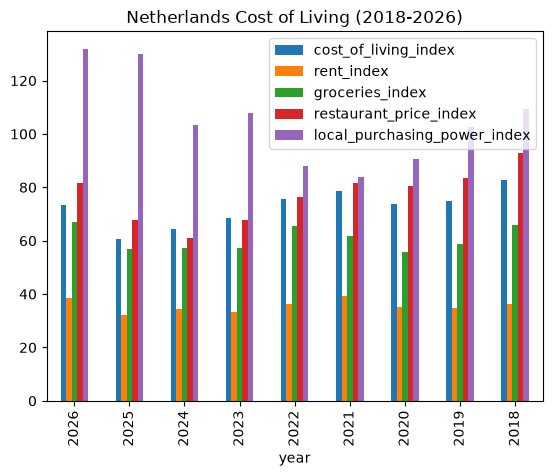

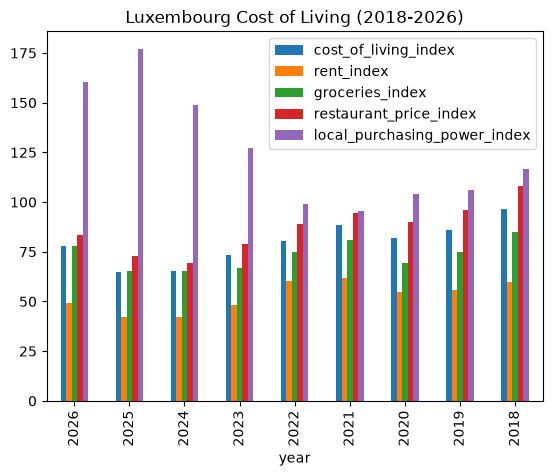

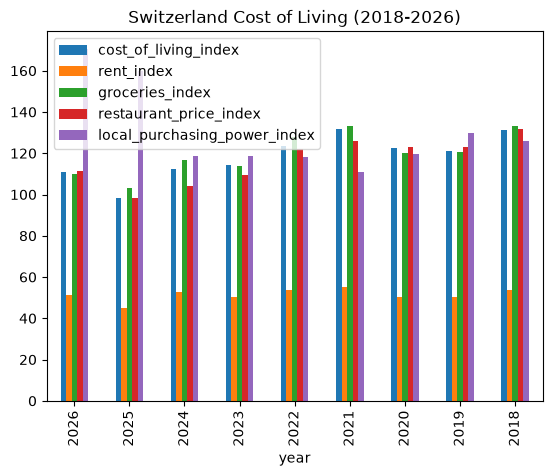

In [8]:
#from "three_countries_df" can you show a bar chart for "Netherlands" "cost_of_living_index", "rent_index", "groceries_index", "restaurant_price_index", "local_purchasing_power_index" in "year" 2018 to 2026
three_countries_df[three_countries_df['country'] == 'Netherlands'].plot(x='year', y=['cost_of_living_index', 'rent_index', 'groceries_index', 'restaurant_price_index', 'local_purchasing_power_index'], kind='bar')
#add name "Netherlands" to the bar chart
plt.title('Netherlands Cost of Living (2018-2026)')

#can you show me the bar chart for "Luxembourg" "cost_of_living_index", "rent_index", "groceries_index", "restaurant_price_index", "local_purchasing_power_index" in "year" 2018 to 2026
three_countries_df[three_countries_df['country'] == 'Luxembourg'].plot(x='year', y=['cost_of_living_index', 'rent_index', 'groceries_index', 'restaurant_price_index', 'local_purchasing_power_index'], kind='bar')
#add name "Luxembourg" to the bar chart
plt.title('Luxembourg Cost of Living (2018-2026)')

#can you show me the bar chart for "Switzerland" "cost_of_living_index", "rent_index", "groceries_index", "restaurant_price_index", "local_purchasing_power_index" in "year" 2018 to 2026
three_countries_df[three_countries_df['country'] == 'Switzerland'].plot(x='year', y=['cost_of_living_index', 'rent_index', 'groceries_index', 'restaurant_price_index', 'local_purchasing_power_index'], kind='bar')
#add name "Switzerland" to the bar chart
plt.title('Switzerland Cost of Living (2018-2026)')


These bar charts are fine as they will give me an idea for what I'm looking for in Tableau, however my first problem here is the "Year" starting at 2026 and descending to 2018!

Looking at these bar charts I can see just after 2018 to 2022 that the bars stabalize, this could possibly be due to COVID-19. I'm not sure of the effects of the pandemic for other countries at the time or for their economies financially.

Having looked at the three bar charts I feel that "Local Purchasing Power" might also conflict with tourism although it is still a good indicator as to What is being spent where. I won't be removing the "Local Purchasing Power" index.

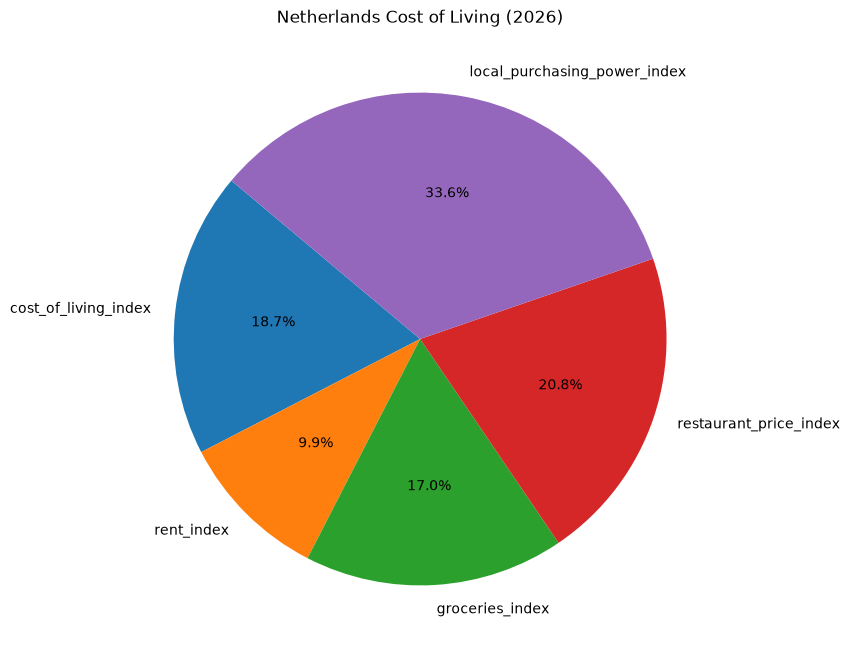

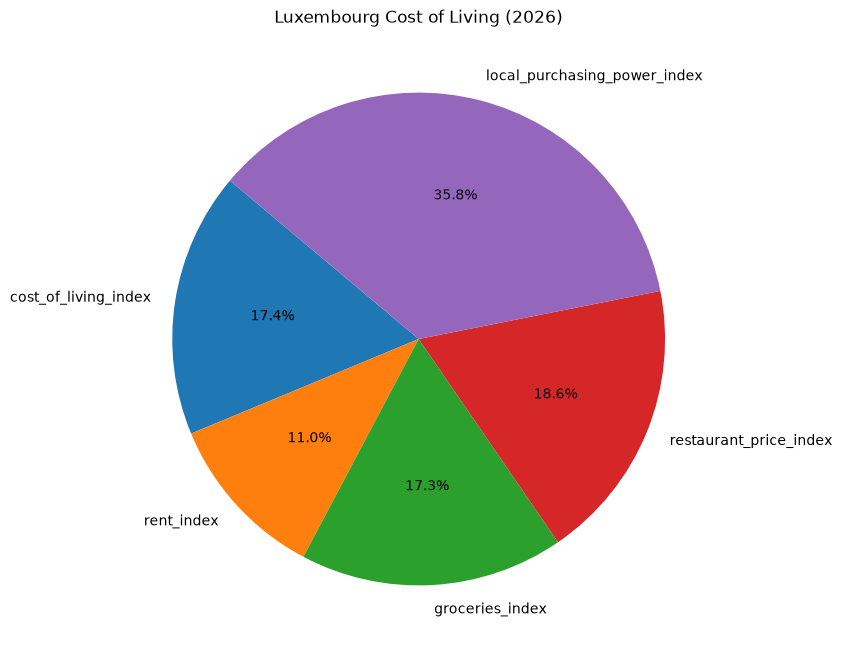

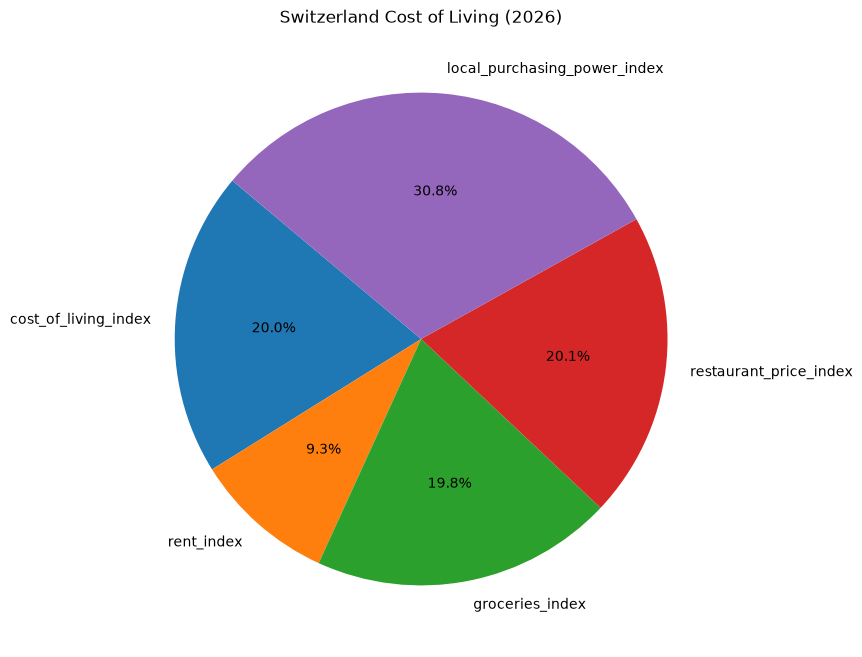

In [9]:
#from "three_countries_df" can you show individual pie charts for "Netherlands", "Luxembourg", and "Switzerland" for "cost_of_living_index", "rent_index", "groceries_index", "restaurant_price_index", and "local_purchasing_power_index" in 2026
# Filter data for the year 2026
df_2026 = three_countries_df[three_countries_df["year"] == 2026]
#create pie charts for each country
for country in ['Netherlands', 'Luxembourg', 'Switzerland']:    
    country_data = df_2026[df_2026['country'] == country]
    indices = ['cost_of_living_index', 'rent_index', 'groceries_index', 'restaurant_price_index', 'local_purchasing_power_index']
    values = country_data[indices].values.flatten()
    
    plt.figure(figsize=(8, 8))
    plt.pie(values, labels=indices, autopct='%1.1f%%', startangle=140)
    plt.title(f'{country} Cost of Living (2026)')
    plt.show()


Having decided to do my usual pie charts, I do think doing a chart for each year (2018-2026) would be tiresome to look at, so I chose most recent 2026. Realising that the dataset gets updated every mid year, that 2026 might be incomplete. 

When I move over to Tableau I might do 2025 so I'm either not too early or too late. I may also leave the pie charts in this case as I want to see and present a scaleable number, not something our of 100%.

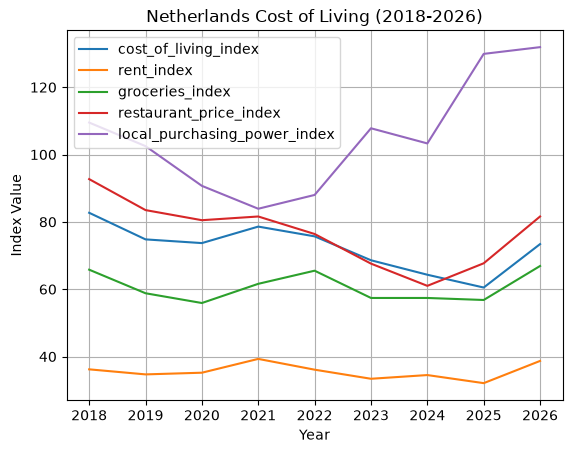

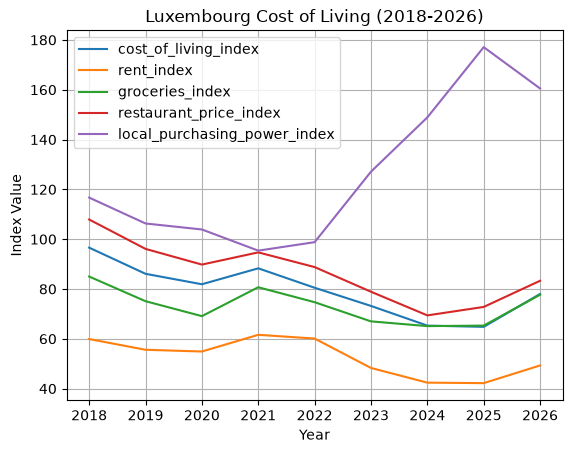

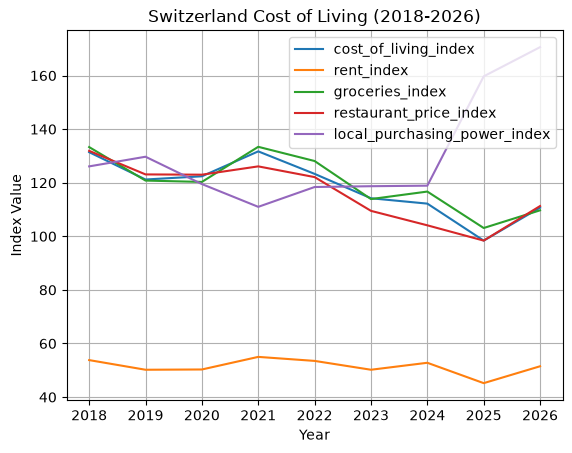

In [10]:
#can you show me individual line charts for "Netherlands", "Luxembourg", and "Switzerland" for "cost_of_living_index", "rent_index", "groceries_index", "restaurant_price_index", and "local_purchasing_power_index" from 2018 to 2026
countries = ["Netherlands", "Luxembourg", "Switzerland"]
#create a line chart for each country
for country in countries:
    country_df = three_countries_df[three_countries_df['country'] == country]
    country_df.plot(x='year', y=['cost_of_living_index', 'rent_index', 'groceries_index', 'restaurant_price_index', 'local_purchasing_power_index'], kind='line')
    plt.title(f'{country} Cost of Living (2018-2026)')
    plt.xlabel('Year')
    plt.ylabel('Index Value')
    plt.grid()
    plt.show()

I think the line charts are a MUST! As I mentioned earlier with the pie charts, the dataset gets udpated every mid term. Looking at the end of the line chart this might be a good predictive way to say that 2027 might increase or decrease in certain keys/columns.

I will definatley include a line chart when moving to Tableau.

## In Tableau

After experimenting in the app version I have finalised what charts I want to present my findings.

https://public.tableau.com/views/HackathonProjectCostofLivinginEurope/Sheet1?:language=en-GB&:sid=&:display_count=n&:origin=viz_share_link

This link is for sheet 1, I have set the Green as low and Red as high. 
I have found Switzerland to be the most expensive out of the three with Cost of Living, Restuarant Prices, Groceries and Local Purchasing Power just in red/pink.

Out of the three I have found Netherlands to be the cheapest, all values are in the green except Local Purchasing Power in pink, which isn't too expensive but compared to Luxembourg which also has all values in green but Local Purchasing Power is in the red.

https://public.tableau.com/views/HackathonProjectCostofLivinginEurope/Sheet2?:language=en-GB&:sid=&:display_count=n&:origin=viz_share_link

This is the link for sheet 2, I want to treat this as near a prediction chart.
I can see between 2020-2022 there is somewhat an anomaly, I mentioned before COVID-19 was between 2018-2022. I think this could be the financial stage (2022-2022) where the countries were stabalizing. After this I can see that some of the values still stabalize with a slight raise, but in terms of predictability I think we will see a slight raise from the three countires.

---

NOTE

* This is the link to my dashboard Tableau
https://public.tableau.com/views/HackathonProjectCostofLivinginEurope/Dashboard1?:language=en-GB&:sid=&:display_count=n&:origin=viz_share_link

---

# Conclusions & Next Steps

Conclusion 
* When working in a team and choosing the dashboards (Streamlit, Power BI & Tableau) we decided to use Streamlit, because I only knew Tableau I wanted to compare against Streamlit. I do think Streamlit looks more professional and powerful in it's presentation power.

Next Steps 
* I will be learning Streamlit for future presentations.

* Now that we have finished Western Europe, the goal is to finish the rest of Europe and if we feel confident and up to the challenge we could concentrate on another region.